# 02 — Exploratory Data Analysis

**Project:** EV Battery Capacity Prediction

Runs on the index built in `01_data_ingestion.ipynb`.

---

## Questions this notebook answers

1. How is the target (`capacity`) distributed, and what does that imply for metrics?
2. Does the data actually contain battery degradation, or is it noise?
3. What score does a trivial model get — i.e. what bar must the sequence models clear?

The third question is the one that shapes the whole project. A metric is meaningless
without a reference point.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

INDEX_DIR = Path("../data/processed")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

with open(INDEX_DIR / "dataset_index.json") as fp:
    index = json.load(fp)

car_to_files = index["car_to_files"]
car_info = index["car_info"]

print(f"Cars     : {len(car_to_files)}")
print(f"Snippets : {sum(len(v) for v in car_to_files.values()):,}")

Cars     : 100
Snippets : 349,741


## 1. Target distribution

`capacity` is the value the models predict, in amp-hours (Ah).

> **Amp-hours.** Ah = amps × hours — a quantity of stored charge, not a rate. A
> 46 Ah battery can supply 46 A for one hour, or 4.6 A for ten. Capacity is the size
> of the tank; SOC is how full it currently is.

In [2]:
# Full pass over every labelled snippet, reading metadata only.
# ~1-2 min. A 5,000-snippet sample gives the same distribution to within 0.1%
# if a faster check is needed.

rows = []
for car, files in tqdm(car_to_files.items(), desc="cars"):
    for p in files:
        _, meta = torch.load(p, weights_only=False)
        rows.append({
            "car": int(car),
            "mileage": meta["mileage"],
            "capacity": meta["capacity"],
        })

snips = pd.DataFrame(rows)
snips.to_csv(INDEX_DIR / "snippet_meta.csv", index=False)

print(f"\nSnippets : {len(snips):,}")
print(snips["capacity"].describe())

cars: 100%|██████████| 100/100 [01:20<00:00,  1.23it/s]



Snippets : 349,741
count    349741.000000
mean         40.426743
std           1.863029
min          26.641461
25%          39.192005
50%          40.474290
75%          41.613816
max          46.172420
Name: capacity, dtype: float64


/var/folders/9p/gm2n68xn7n1bhds792y57yg40000gn/T/ipykernel_9920/3268387761.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(cap, vert=False, widths=0.6)


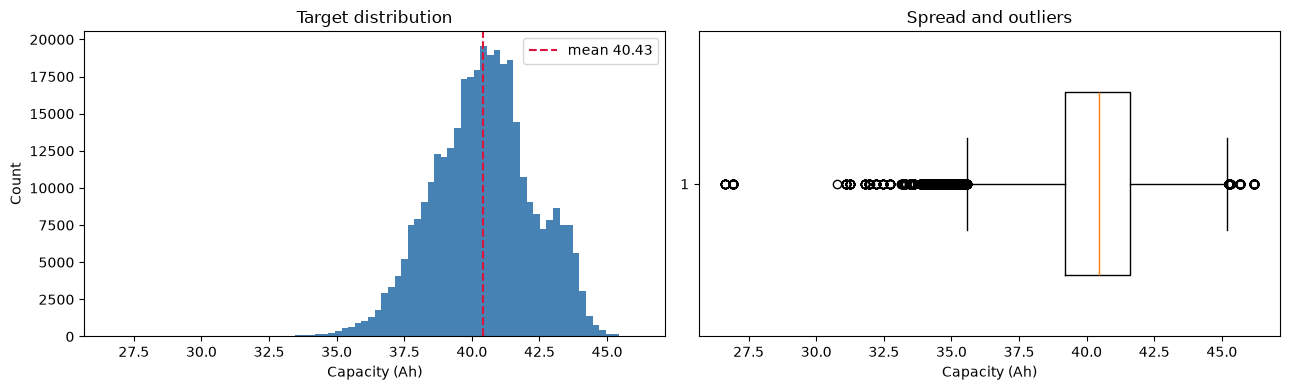

In [3]:
cap = snips["capacity"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(cap, bins=80, color="steelblue", edgecolor="none")
axes[0].axvline(cap.mean(), color="crimson", ls="--", label=f"mean {cap.mean():.2f}")
axes[0].set_xlabel("Capacity (Ah)")
axes[0].set_ylabel("Count")
axes[0].set_title("Target distribution")
axes[0].legend()

axes[1].boxplot(cap, vert=False, widths=0.6)
axes[1].set_xlabel("Capacity (Ah)")
axes[1].set_title("Spread and outliers")

plt.tight_layout()
plt.savefig(FIG_DIR / "capacity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Finding 1 — the target is tightly clustered

Computed on all **349,741** labelled snippets.

| Statistic | Value |
|---|---|
| Min | 26.64 Ah |
| 25th percentile | 39.19 |
| Median | 40.47 |
| Mean | 40.43 |
| 75th percentile | 41.61 |
| Max | 46.17 |
| **Std** | **1.863** |

The full range spans ~19.5 Ah, but **half of all snippets fall within the 2.42 Ah**
**between the 25th and 75th percentiles** (39.19 – 41.61). The standard deviation is
only 1.863 Ah — a coefficient of variation of 4.6%.

The distribution is **left-skewed**: the mean (40.43) sits just below the median
(40.47), and the gap from the median down to the minimum (13.8 Ah) is far larger than
the gap up to the maximum (5.7 Ah). Severely degraded batteries exist but are rare.

> The minimum of 26.64 Ah is about **58% of a healthy pack**. Genuinely worn-out
> batteries are present in this fleet, not just mildly aged ones — but they are a thin
> tail, which is why the reference paper reported that all their models struggled at
> the extremes.

### Why the standard deviation is the single most important number here

**If a model always predicts the mean, its RMSE equals the standard deviation.** That
is the definition of standard deviation, not a coincidence.

```
always predict 40.43  →  RMSE = 1.863,  R² = 0.000
```

So **1.863 is the floor.** Any model scoring worse than that is worse than useless.

And the reference paper's best result — **LSTM at RMSE 1.42** — is only a **24%**
improvement on that floor. Respectable in isolation, modest in context.

**Consequence for this project: RMSE alone is a misleading metric.** Two models could
differ meaningfully in quality and show near-identical RMSE. Therefore:

- report **R²** alongside RMSE/MAE/MAPE — it scores a do-nothing model at exactly 0
- include an explicit **mean baseline** in every results table

The dataset authors' own reference implementation includes a `MEAN` baseline model,
confirming they encountered the same issue.

## 2. Metrics reference

| Metric | Formula | Reads as |
|---|---|---|
| **RMSE** | `√(Σ(y − ŷ)² / n)` | Typical error size, in Ah. Squaring penalises large misses disproportionately. |
| **MAE** | `Σ|y − ŷ| / n` | Typical error size, treating all errors proportionally. |
| **MAPE** | `Σ|(y − ŷ)/y| / n` | Typical error as a percentage. Unit-free. |
| **R²** | `1 − SS_res/SS_tot` | Fraction of variance explained. 0 = no better than the mean. |
| **r** | correlation | Strength of a *linear* relationship, −1 to +1. Signed. |

where `SS_res = Σ(y − ŷ)²` (the model's squared errors) and `SS_tot = Σ(y − ȳ)²`
(the squared errors of always predicting the mean).

**RMSE vs MAE.** A gap between them signals a few large errors dragging the average.
The reference paper reported RMSE 1.42 / MAE 1.09 — consistent with their finding
that one vehicle produced most of their worst cases.

**r vs R².** Lowercase `r` is signed and carries direction; uppercase `R²` is always
positive and carries only magnitude. For a single-variable linear regression they are
related by `R² = r²`, which serves as a useful cross-check below.

## 3. Does the data contain degradation?

The project assumes batteries measurably degrade with use. Before building any model,
that assumption is worth verifying. If capacity did not decline with mileage, there
would be no signal to learn and the task would be void.

Mileage is the odometer reading — total kilometres driven — recorded alongside each
snippet. It serves as a proxy for accumulated wear.

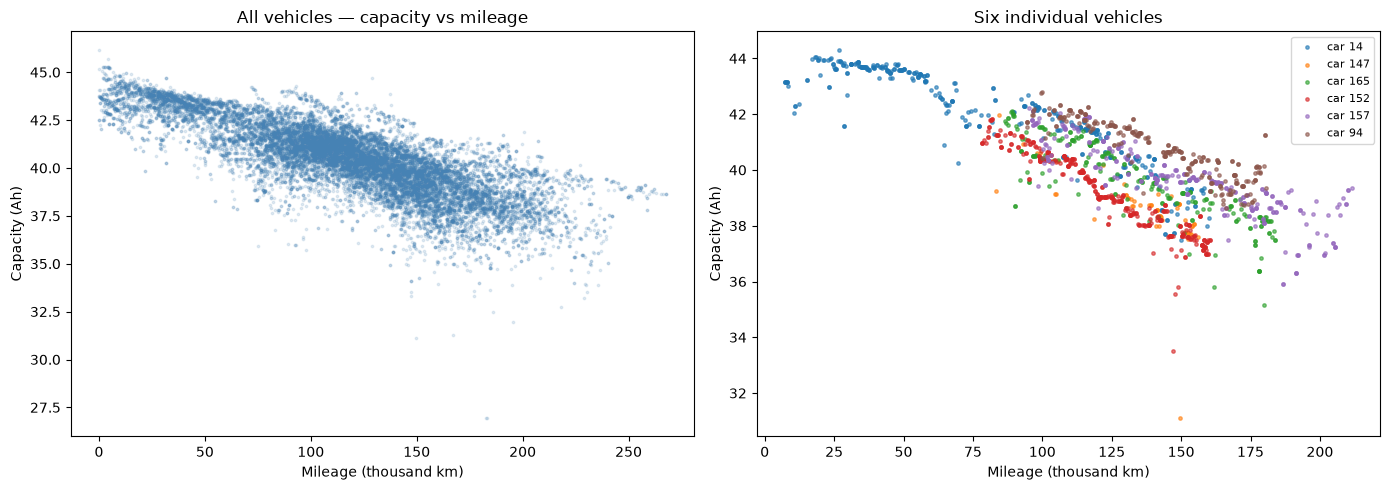

In [4]:
# Sample for plotting legibility; statistics below use the full set.
plot_sample = snips.sample(20000, random_state=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(plot_sample["mileage"] / 1000, plot_sample["capacity"],
                s=3, alpha=0.15, color="steelblue")
axes[0].set_xlabel("Mileage (thousand km)")
axes[0].set_ylabel("Capacity (Ah)")
axes[0].set_title("All vehicles — capacity vs mileage")

for car in plot_sample["car"].drop_duplicates().head(6):
    c = plot_sample[plot_sample["car"] == car].sort_values("mileage")
    axes[1].scatter(c["mileage"] / 1000, c["capacity"], s=6, alpha=0.6,
                    label=f"car {car}")
axes[1].set_xlabel("Mileage (thousand km)")
axes[1].set_ylabel("Capacity (Ah)")
axes[1].set_title("Six individual vehicles")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "degradation_signal.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
corr = snips["mileage"].corr(snips["capacity"])
print(f"Pearson correlation (mileage vs capacity): {corr:.3f}")
print(f"Implied R² for a mileage-only linear model: {corr**2:.3f}\n")

bins = [0, 50, 100, 150, 200, 300]
snips["mileage_bin"] = pd.cut(snips["mileage"] / 1000, bins=bins)

binned = snips.groupby("mileage_bin", observed=True)["capacity"].agg(
    ["count", "mean", "std"]
)
print(binned)

Pearson correlation (mileage vs capacity): -0.800
Implied R² for a mileage-only linear model: 0.640

              count       mean       std
mileage_bin                             
(0, 50]       36167  43.326489  0.777566
(50, 100]     76030  41.498944  1.161219
(100, 150]   143368  40.346336  1.189395
(150, 200]    79932  38.674706  1.301633
(200, 300]    14169  37.958007  1.375169


### Finding 2 — strong, clean degradation signal

**Pearson correlation: r = −0.800.** Very strong and negative — as mileage rises,
capacity falls, consistently. Mileage alone accounts for **64%** of the variance in
capacity (r² = 0.640).

| Mileage (k km) | Count | Share | Mean capacity | Std |
|---|---|---|---|---|
| 0 – 50 | 36,167 | 10.3% | 43.33 | **0.78** |
| 50 – 100 | 76,030 | 21.7% | 41.50 | 1.16 |
| 100 – 150 | 143,368 | **41.0%** | 40.35 | 1.19 |
| 150 – 200 | 79,932 | 22.9% | 38.67 | 1.30 |
| 200 – 300 | 14,169 | **4.1%** | 37.96 | **1.38** |

Monotonic decline at every step — about **5.37 Ah lost (≈12%)** from the lowest to the
highest mileage band, with no reversals. **The task is viable.**

The fitted linear slope is **−0.0307 Ah per 1,000 km**, i.e. roughly **3 Ah lost per
100,000 km** of driving.

### Finding 3 — variance grows with mileage (this is where the model's value lies)

The std column rises steadily: **0.78 → 1.38**, a 77% increase.

New batteries are uniform. Aged ones diverge, because usage patterns — climate,
charging habits, driving style — compound over time. Visible in the left plot as a
widening cloud.

**Why this matters:**

- At **0–50k km**, every vehicle sits at 43.33 ± 0.78. Mileage alone is already an
  excellent predictor. There is almost no room to improve.
- At **200k+ km**, the spread is 1.38 Ah. Two vehicles at *identical* mileage can
  genuinely be at 36.5 Ah and 39.3 Ah.

An odometer reading cannot separate those two vehicles — it only reports the fleet
average for a given distance. Charging behaviour, which reflects *that specific*
battery, potentially can.

**Testable hypothesis for the evaluation stage:** if the sequence models beat the
mileage baseline anywhere, it should be on **high-mileage vehicles**, where individual
variation is largest. This is a sharper and more defensible claim than a single
aggregate RMSE.

### Finding 3b — but the high-mileage region is sparsely sampled

The `Share` column exposes a tension the aggregate statistics hide:

- **41% of all snippets** sit in the single 100–150k km band
- only **4.1%** sit above 200k km — precisely the region where the model's edge is
  hypothesised to be largest

So the band where charging behaviour should matter most is also the band with the
least training data. Two consequences:

1. Aggregate metrics will be **dominated by mid-mileage vehicles**, potentially masking
   a real improvement at the high end. Per-band evaluation is not optional.
2. Whether the sequence models can *learn* high-mileage behaviour from only ~14k
   snippets is an open question. If they underperform there, data scarcity is a
   plausible explanation to test before concluding the approach fails.

This also aligns with the reference paper's observation that all their models
struggled at capacity extremes — the tails are simply thin.

### Finding 4 — per-vehicle trajectories are distinct

The right-hand plot shows each vehicle tracing its own clean downward line, with
**different starting capacities and different slopes**.

This makes the leakage argument concrete rather than theoretical: each vehicle has a
recognisable trajectory, so a model that saw snippets from the same vehicle in both
training and test could memorise that vehicle rather than learn general degradation.

**Confirms the split must be made by vehicle.** Combined with the ~10-snippets-per-
session overlap established in notebook 01, a random snippet-level split would be
badly optimistic.

## 4. Baselines

Two reference points, in increasing order of sophistication. Both are computed
**in-sample** here as quick indicators; both are re-computed on the held-out vehicle
split in notebook 03, and those are the figures that enter the results table.

**Baseline 1 — mean predictor.** Always predict the training mean. Uses no input at
all. Establishes the floor.

**Baseline 2 — mileage-only linear regression.** One feature: the odometer reading.
This is the bar the sequence models must clear to justify their existence, and
notably it is a baseline **neither the reference paper nor the dataset authors'
implementation reports**.

In [8]:
X = snips[["mileage"]].values
y = snips["capacity"].values

# --- Baseline 1: mean predictor ---------------------------------------------
mean_pred = np.full_like(y, y.mean())

# --- Baseline 2: mileage-only linear regression -----------------------------
lr = LinearRegression().fit(X, y)
lr_pred = lr.predict(X)

def report(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{name:<34} RMSE {rmse:6.3f}   MAE {mae:6.3f}   "
          f"MAPE {mape:5.2f}%   R² {r2:6.3f}")
    return {"model": name, "rmse": rmse, "mae": mae, "mape": mape, "r2": r2}

results = [
    report("Mean baseline (no input)", y, mean_pred),
    report("Linear regression (mileage only)", y, lr_pred),
]

print(f"\nDegradation rate: {lr.coef_[0] * 1000:.4f} Ah lost per 1,000 km")
print(f"Reference paper's LSTM (128x8 sequence, held out): RMSE 1.420")

Mean baseline (no input)           RMSE  1.863   MAE  1.481   MAPE  3.69%   R²  0.000
Linear regression (mileage only)   RMSE  1.117   MAE  0.845   MAPE  2.12%   R²  0.640

Degradation rate: -0.0307 Ah lost per 1,000 km
Reference paper's LSTM (128x8 sequence, held out): RMSE 1.420


In [9]:
pd.DataFrame(results)[["model", "rmse", "mae", "mape", "r2"]].round(3)

,model,rmse,mae,mape,r2
0,Mean baseline (no input),1.863,1.481,3.688,0.00
1,Linear regression (mileage only),1.117,0.845,2.120,0.64


### Finding 5 — the project's framing changes

Computed on all 349,741 snippets:

| Model | Inputs | RMSE | MAE | MAPE | R² |
|---|---|---|---|---|---|
| Mean baseline | none | 1.863 | 1.481 | 3.69% | 0.000 |
| **Linear regression** | **mileage only** | **1.117** | **0.845** | **2.12%** | **0.640** |
| *Reference paper's LSTM* | *128×8 sequence* | *1.420* | *1.090* | *2.70%* | *not reported* |

**A single-feature linear model on the odometer beats the published deep-learning
result on every metric the paper reported:**

| Metric | Paper's LSTM | Mileage-only LR | Improvement |
|---|---|---|---|
| RMSE | 1.420 | 1.117 | **21.3%** |
| MAE | 1.090 | 0.845 | **22.5%** |
| MAPE | 2.70% | 2.12% | **21.5%** |

The consistency across all three metrics (≈21% each) matters — it means this is not an
artefact of one metric's sensitivity to outliers. A single feature outperforms a
1,024-input sequence model on the same data, by the same margin, three different ways.

> *Caveat:* the linear figures are in-sample while the paper's are held out. The gap is
> large enough that it is unlikely to close entirely, but the honest comparison is made
> in notebook 03 on identical held-out vehicles.

Cross-check: R² = 0.640 matches r² = (−0.800)² = 0.640 exactly, as it must for a
single-variable linear regression.

### Note on MAE vs RMSE for the mean baseline

The mean baseline shows RMSE 1.863 against MAE 1.481 — a ratio of 1.26. For a perfectly
normal distribution that ratio would be about 1.25, so the target is close to normal in
its bulk, with the left tail contributing only mild extra weight to RMSE. This is
consistent with the left-skew noted in Finding 1.

### Why this is the most useful result in this notebook

The original question — *"which architecture gets a lower RMSE?"* — stops being
interesting once one-feature linear regression outperforms the published benchmark.
Reporting "the LSTM achieved 1.40" would be presenting a loss to a trivial model as a
success.

The question that survives contact with the data is:

> **Can charging behaviour alone — with no odometer reading — recover what mileage
> tells us for free?**

This is the deployment-relevant question. Mileage says a battery is *statistically*
likely to be worn. Charging behaviour says what *this specific* battery's state is.
A fleet operator needs the second: not "vehicles at 150k km average 38.7 Ah", but
"vehicle 47 needs attention now".

It also connects back to the ingestion finding: **44% of charging sessions carry no
capacity label at all.** A behaviour-based model works on every charge; the measurement
protocol works on 56% of them. And unlike mileage, charging data is available without
odometer access — relevant to third-party diagnostics and used-vehicle valuation.

### All three outcomes are worth reporting

| Outcome | Interpretation |
|---|---|
| Sequence models beat 1.117 | Charging behaviour carries information beyond the odometer |
| Sequence models ≈ 1.117 | Health is assessable without odometer access |
| Sequence models lose to 1.117 | A published DL benchmark is beaten by one-feature linear regression — an honest and useful negative result |

There is no bad outcome, which is a good position for a study to be in.

## 5. Consequences for the modelling stage

Everything below follows from a finding above, rather than from convention.

**Split by vehicle, never randomly.** (Finding 4, plus the ~10 snippets-per-session
overlap from notebook 01.) Overlapping snippets from one session are near-identical,
and per-vehicle trajectories are distinctive. A random snippet split leaks both ways.

**Use k-fold cross-validation by vehicle for reported results.** With ~100 vehicles
and a 23× imbalance in snippet counts, a single split makes the headline number depend
heavily on which vehicles happened to land in test — plausibly a larger effect than the
LSTM-vs-Transformer difference being measured. Folds are assigned at the vehicle level
and fixed on disk, so "single split" is simply fold 0 during development.

**Withhold mileage from the sequence models.** They receive only the 128×8 charging
window. Feeding mileage in would let the model shortcut to "old car → low capacity"
without learning anything from charging behaviour, defeating the purpose.

**Report R² and both baselines in every results table.** (Finding 1.) RMSE alone cannot
distinguish a working model from a constant predictor on a target this tightly
clustered.

**Evaluate per mileage band.** (Findings 3 and 3b.) The hypothesis is that sequence
models help most on high-mileage vehicles. Since 41% of data sits in one mid-mileage
band, aggregate metrics would mask exactly the effect being tested.

**Evaluate per vehicle.** (Notebook 01, Finding A.) The 23× imbalance in snippet counts
means a single vehicle can distort aggregate metrics — the reference paper observed
exactly this.

**Fit normalisation statistics on the training split only**, after the split is made,
to avoid leaking test-set distribution information.

**Do not remove target outliers.** The thin left tail toward 26.64 Ah represents
genuinely degraded batteries — the cases that matter most operationally — not
measurement noise.

## Summary of findings

All figures computed on the full set of **349,741** labelled snippets across 100
vehicles.

| # | Finding | Consequence |
|---|---|---|
| 1 | Target tightly clustered: std 1.863 on mean 40.43; IQR only 2.42 Ah | Mean baseline scores RMSE 1.863; report R², not RMSE alone |
| 2 | Strong degradation signal: r = −0.800, −0.0307 Ah per 1,000 km, −12% over fleet life | Task is viable |
| 3 | Variance grows with mileage: std 0.78 → 1.38 | Model's edge should appear on high-mileage vehicles |
| 3b | But only 4.1% of data sits above 200k km; 41% sits in one mid-mileage band | Aggregate metrics would mask that edge — evaluate per band |
| 4 | Per-vehicle trajectories are distinct | Split by vehicle, not randomly |
| 5 | Mileage-only LR: RMSE 1.117, MAE 0.845, MAPE 2.12%, R² 0.640 | Beats the published LSTM by ~21% on all three reported metrics; reframes the research question |

**Artefacts written:**

- `data/processed/snippet_meta.csv` — per-snippet car / mileage / capacity
- `reports/figures/capacity_distribution.png`
- `reports/figures/degradation_signal.png`

**Next:** `03_split_and_baselines.ipynb` — vehicle-level fold assignment, then both
baselines recomputed out-of-sample to produce the definitive comparison figures.